In [9]:
from sklearn.model_selection import KFold, cross_validate, RepeatedKFold
from sklearn.preprocessing import PowerTransformer,  StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression, HuberRegressor

from ml_enhance import CorrelationFilter, StatisticalComparison

from sklearn import pipeline
import pandas as pd
import numpy as np
import pickle
import json

In [10]:
def make_pipeline(model, step_name):
    return pipeline.Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("remove_corr", CorrelationFilter(threshold=0.95)),
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", StandardScaler()),
        (step_name, model)
    ])

In [11]:
pl_linear = make_pipeline(LinearRegression(), "predict")
pl_huber = make_pipeline(HuberRegressor(), "predict")

As the data (even after transformation and scaling) consists of a lot of outliers that cannot be removed (as they are valid molecules and are therefore part of the real world observables) I decided to use [Huber regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html) instead of linear regression, this method is more robust to outliers.

In [12]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm2.csv")

In [13]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [ ]:
X = X.drop([
        "avg_atomic_quadrupole_principal_invariant_3", # quadrupole principal invariant 3 features correlate highly with the invariant 2 features, so can drop them
        "max_atomic_quadrupole_principal_invariant_3",
        "molecular_quadrupole_principal_invariant_3",
        "avg_atomic_dipole_dipole_interaction" # the dipole dipole interaction between atoms would physically not be that influential on the solubility, can drop it
    ], axis=1)

In [15]:
with open("../data/rdkit_feature_names.json", "r") as f:
    rdkit_feature_list: list = json.load(f)

mask = X.columns.isin(rdkit_feature_list)

In [16]:
X_topo = X.iloc[:, mask]
X_qm = X.iloc[:, ~mask]

## Huber Regression: Topology VS. QM + Topology

In [17]:
inner_kf = KFold(n_splits=5, shuffle=True, random_state=42)
repeated_kf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=15)

In [18]:
scoring = {
    "r2": "r2",
    "MSE": "neg_mean_squared_error"
}

In [19]:
param_grid = {
    "predict__epsilon": [1.1, 1.35, 1.5, 2.0],
    "predict__alpha": [1e-5, 1e-4, 1e-3, 1e-2]
}

In [20]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=pl_huber,
    param_grid=param_grid,
    cv=inner_kf,
    scoring='r2',
    n_jobs=1
)

In [21]:
# scores_combo = cross_validate(grid, X, y, cv=repeated_kf, scoring=scoring, n_jobs=5, return_estimator=True, return_train_score=True, verbose=12)

# with open("HuberReg_combo2.pkl", "wb") as f:
#     pickle.dump(scores_combo, f)

In [22]:
# scores_topo = cross_validate(grid, X_topo, y, cv=repeated_kf, scoring=scoring, n_jobs=5, return_estimator=True, return_train_score=True, verbose=12)

# with open("HuberReg_topo.pkl", "wb") as f:
#     pickle.dump(scores_topo, f)

In [24]:
# scores_qm = cross_validate(grid, X_qm, y, cv=repeated_kf, scoring=scoring, n_jobs=5, return_estimator=True, return_train_score=True, verbose=12)

# with open("HuberReg_qm2.pkl", "wb") as f:
#     pickle.dump(scores_qm, f)

In [25]:
with open("HuberReg_combo2.pkl", "rb") as f:
    scores_combo = pickle.load(f)

with open("HuberReg_topo.pkl", "rb") as f:
    scores_topo = pickle.load(f)

with open("HuberReg_qm2.pkl", "rb") as f:
    scores_qm = pickle.load(f)

In [26]:
for idx in range(25):
    print(scores_combo["estimator"][idx].best_score_, scores_combo["estimator"][idx].best_params_)

0.7977729498486463 {'predict__alpha': 0.001, 'predict__epsilon': 1.5}
0.8309336302958524 {'predict__alpha': 0.001, 'predict__epsilon': 1.5}
0.6229619209432113 {'predict__alpha': 0.01, 'predict__epsilon': 1.35}
0.8231861648766277 {'predict__alpha': 0.001, 'predict__epsilon': 2.0}
0.8241982337267636 {'predict__alpha': 0.01, 'predict__epsilon': 2.0}
0.823897849907991 {'predict__alpha': 0.0001, 'predict__epsilon': 2.0}
0.7887658406474495 {'predict__alpha': 0.0001, 'predict__epsilon': 1.35}
0.7867982771780266 {'predict__alpha': 1e-05, 'predict__epsilon': 1.1}
0.8234588410574977 {'predict__alpha': 1e-05, 'predict__epsilon': 2.0}
0.8216914270835758 {'predict__alpha': 0.0001, 'predict__epsilon': 1.35}
0.831555377693175 {'predict__alpha': 1e-05, 'predict__epsilon': 2.0}
0.8242503061141685 {'predict__alpha': 0.0001, 'predict__epsilon': 1.5}
0.6649040819838283 {'predict__alpha': 1e-05, 'predict__epsilon': 1.1}
0.8271256739761567 {'predict__alpha': 0.001, 'predict__epsilon': 1.5}
0.823811004423161

In [27]:
print(f"Train R2 scores:\nTopology alone: {scores_topo["train_r2"].mean()}\nQM alone: {scores_qm["train_r2"].mean()}\nCombined: {scores_combo["train_r2"].mean()}")
print("\n")
print(f"Test R2 scores:\nTopology alone: {scores_topo["test_r2"].mean()}\nQM alone: {scores_qm["test_r2"].mean()}\nCombined: {scores_combo["test_r2"].mean()}")

Train R2 scores:
Topology alone: 0.8285804700797548
QM alone: 0.7785148066552887
Combined: 0.8453697078048785


Test R2 scores:
Topology alone: 0.8167036119426834
QM alone: 0.7669939126664752
Combined: 0.821993110019026


In [28]:
n_tot = X.shape[0]
n_train = n_tot * 4 // 5  
n_test = n_tot - n_train

In [35]:
topo_r2s = scores_topo["test_r2"]
combo_r2s = scores_combo["test_r2"]

comparator = StatisticalComparison(combo_r2s, topo_r2s)
ttest_result =  comparator.nadeau_bengio_corrected_t_test(n_train, n_test)
wilcoxon_result = comparator.wilcoxon_fold_differences()

print("Topo mean r2:", np.abs(topo_r2s).mean())
print("Combined mean r2:", np.abs(combo_r2s).mean())
print("Mean improvement:", ttest_result["mean_diff"])
print(f"T-test p-value: {ttest_result["p_value"]} ->{' not' if ttest_result["p_value"] > 0.05 else ''} statistically significant")
print(f"Wilcoxon p-value: {wilcoxon_result['p_value_w']} ->{' not' if wilcoxon_result['p_value_w'] > 0.05 else ''} statistically significant")

Topo mean r2: 0.8167036119426834
Combined mean r2: 0.821993110019026
Mean improvement: 0.005289498076342447
T-test p-value: 0.18170227245102288 -> not statistically significant
Wilcoxon p-value: 0.0018156766891479492 -> statistically significant


In [36]:
print(f"Train MSE scores:\nTopology alone: {np.abs(scores_topo["train_MSE"]).mean()}\nQM alone: {np.abs(scores_qm["train_MSE"]).mean()}\nCombined: {np.abs(scores_combo["train_MSE"]).mean()}")
print("\n")
print(f"Test MSE scores:\nTopology alone: {np.abs(scores_topo["test_MSE"]).mean()}\nQM alone: {np.abs(scores_qm["test_MSE"]).mean()}\nCombined: {np.abs(scores_combo["test_MSE"]).mean()}")

Train MSE scores:
Topology alone: 0.912975039765269
QM alone: 1.1796105261010412
Combined: 0.8235597408453944


Test MSE scores:
Topology alone: 0.975305819976433
QM alone: 1.2396607583001633
Combined: 0.9472593891963412


In [37]:
topo_MSEs = scores_topo["test_MSE"]
combo_MSEs = scores_combo["test_MSE"]

comparator = StatisticalComparison(combo_MSEs, topo_MSEs)
ttest_result =  comparator.nadeau_bengio_corrected_t_test(n_train, n_test)
wilcoxon_result = comparator.wilcoxon_fold_differences()

print("Topo mean MSE:", np.abs(topo_MSEs).mean())
print("Combined mean MSE:", np.abs(combo_MSEs).mean())
print("Mean improvement:", ttest_result["mean_diff"])
print(f"T-test p-value: {ttest_result["p_value"]} ->{' not' if ttest_result["p_value"] > 0.05 else ''} statistically significant")
print(f"Wilcoxon p-value: {wilcoxon_result['p_value_w']} ->{' not' if wilcoxon_result['p_value_w'] > 0.05 else ''} statistically significant")

Topo mean MSE: 0.975305819976433
Combined mean MSE: 0.9472593891963412
Mean improvement: 0.028046430780091915
T-test p-value: 0.18891478861619992 -> not statistically significant
Wilcoxon p-value: 0.002025127410888672 -> statistically significant


Based on the results i got from the Huber regression, the QM descriptors alone seem to give the worst performance out of the three and **there seems to be a small significant difference between the topological descriptors alone and the combined feature set**. The combined set of features provides a slightly better prediction. Whether this is truely because of the QM descriptors, or because of model bias should be analyzed by looking at other models (RF, GAM, KRR?)

In [97]:
from collections import Counter

all_params = [estimator.best_params_ for estimator in scores_combo["estimator"]]

count = Counter(tuple(p.items()) for p in all_params)
most_common = count.most_common(1)
best_params = dict(most_common[0][0])
best_params

{'predict__alpha': 0.01, 'predict__epsilon': 2.0}

In [64]:
def get_FI(estimator, how_many=20):
    FI = dict(zip(estimator.best_estimator_[:-1].get_feature_names_out(), estimator.best_estimator_[-1].coef_))
    sorted_FI = dict(sorted(FI.items(), key=lambda item: abs(item[1]), reverse=True))
    keys = list(sorted_FI.keys())[:how_many]
    values = list(sorted_FI.values())[:how_many]
    return keys, values

In [74]:
best_combo_idx = scores_combo["test_r2"].argmax()
best_combo = scores_combo["estimator"][best_combo_idx]
keys_combo, values_combo = get_FI(best_combo)


best_topo_idx = scores_topo["test_r2"].argmax()
best_topo = scores_topo["estimator"][best_topo_idx]
keys_topo, values_topo = get_FI(best_topo)

best_qm_idx = scores_qm["test_r2"].argmax()
best_qm = scores_qm["estimator"][best_qm_idx]
keys_qm, values_qm = get_FI(best_qm)

In [78]:
best_combo.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance', ...), ('remove_corr', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,threshold,0.95
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",False
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


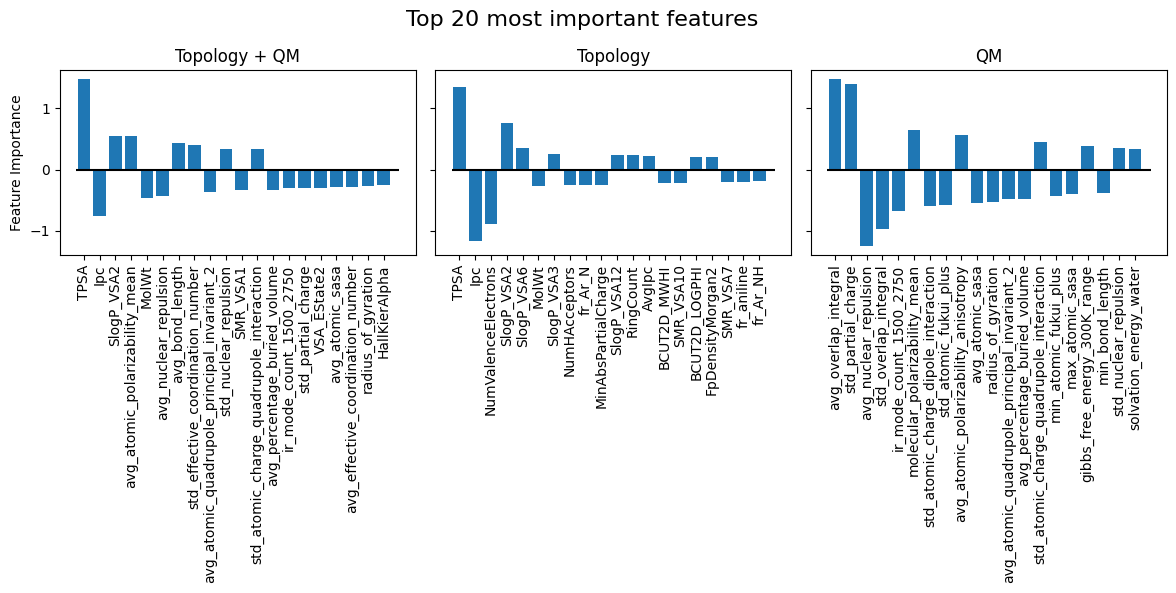

In [75]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

ax1.bar(keys_combo, values_combo)
ax2.bar(keys_topo, values_topo)
ax3.bar(keys_qm, values_qm)

ax1.hlines(0, -0.5, 20, "black")
ax2.hlines(0, -0.5, 20, "black")
ax3.hlines(0, -0.5, 20, "black")

ax1.tick_params(axis='x', rotation=90)
ax2.tick_params(axis='x', rotation=90)
ax3.tick_params(axis='x', rotation=90)

ax1.set_title("Topology + QM")
ax2.set_title("Topology")
ax3.set_title("QM")

ax1.set_ylabel("Feature Importance")

plt.suptitle("Top 20 most important features", fontsize=16)
plt.tight_layout()
plt.show()

I want to try some feature combinations with the QFP features purely focussing on the quantum features, and leaving out the topology based features.

In [42]:
drop_qm_features = [
    'radius_of_gyration',
    'molecular_volume',
    'sterimol_L',
    'sterimol_Bmin',
    'sterimol_Bmax',
    'molecular_sasa',
    'solvation_energy_thf',
    'solvation_energy_cyclohexane',
    'solvation_energy_dmso',
    'avg_percentage_buried_volume',
    'min_percentage_buried_volume',
    'max_percentage_buried_volume',
    'std_percentage_buried_volume',
    'avg_atomic_sasa',
    'min_atomic_sasa',
    'max_atomic_sasa',
    'std_atomic_sasa',
    'min_partial_charge_thf',
    'max_partial_charge_thf',
    'std_partial_charge_thf',
    'min_partial_charge_cyclohexane',
    'max_partial_charge_cyclohexane',
    'std_partial_charge_cyclohexane',
    'min_partial_charge_dmso',
    'max_partial_charge_dmso',
    'std_partial_charge_dmso',
    'avg_bond_length',
    'min_bond_length',
    'max_bond_length',
    'std_bond_length',
    'avg_bond_stiffness',
    'min_bond_stiffness',
    'max_bond_stiffness',
    'std_bond_stiffness',
]

drop_topo_features = [
    'MaxPartialCharge',
    'MinPartialCharge',
    'MaxAbsPartialCharge',
    'MinAbsPartialCharge',
]

In [44]:
X_qm_pure = X_qm.drop(drop_qm_features, axis=1)
X_topo_pure = X_topo.drop(drop_topo_features, axis=1)

In [53]:
X_combo_pure = pd.concat([X_qm_pure, X_topo_pure], axis=1)

In [54]:
# scores_combo_pure = cross_validate(grid, X_combo_pure, y, cv=repeated_kf, scoring=scoring, n_jobs=5, return_estimator=True, return_train_score=True, verbose=12)

# with open("HuberReg_combo_pure.pkl", "wb") as f:
#     pickle.dump(scores_combo_pure, f)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   1 tasks      | elapsed: 22.2min
[Parallel(n_jobs=5)]: Done   2 tasks      | elapsed: 22.3min
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed: 22.4min
[Parallel(n_jobs=5)]: Done   4 tasks      | elapsed: 22.7min
[Parallel(n_jobs=5)]: Done   5 tasks      | elapsed: 22.9min
[Parallel(n_jobs=5)]: Done   6 tasks      | elapsed: 41.6min
[Parallel(n_jobs=5)]: Done   7 tasks      | elapsed: 41.7min
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed: 41.8min
[Parallel(n_jobs=5)]: Done   9 tasks      | elapsed: 42.4min
[Parallel(n_jobs=5)]: Done  10 tasks      | elapsed: 42.6min
[Parallel(n_jobs=5)]: Done  11 tasks      | elapsed: 60.1min
[Parallel(n_jobs=5)]: Done  12 tasks      | elapsed: 60.2min
[Parallel(n_jobs=5)]: Done  13 tasks      | elapsed: 60.4min
[Parallel(n_jobs=5)]: Done  14 tasks      | elapsed: 61.5min
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed: 61.5min
[Parallel(

In [55]:
# scores_topo_pure = cross_validate(grid, X_topo_pure, y, cv=repeated_kf, scoring=scoring, n_jobs=5, return_estimator=True, return_train_score=True, verbose=12)

# with open("HuberReg_topo_pure.pkl", "wb") as f:
#     pickle.dump(scores_topo_pure, f)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   1 tasks      | elapsed: 10.6min
[Parallel(n_jobs=5)]: Done   2 tasks      | elapsed: 10.6min
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed: 10.7min
[Parallel(n_jobs=5)]: Done   4 tasks      | elapsed: 10.9min
[Parallel(n_jobs=5)]: Done   5 tasks      | elapsed: 10.9min
[Parallel(n_jobs=5)]: Done   6 tasks      | elapsed: 21.1min
[Parallel(n_jobs=5)]: Done   7 tasks      | elapsed: 21.1min
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed: 21.2min
[Parallel(n_jobs=5)]: Done   9 tasks      | elapsed: 21.6min
[Parallel(n_jobs=5)]: Done  10 tasks      | elapsed: 21.8min
[Parallel(n_jobs=5)]: Done  11 tasks      | elapsed: 31.6min
[Parallel(n_jobs=5)]: Done  12 tasks      | elapsed: 31.7min
[Parallel(n_jobs=5)]: Done  13 tasks      | elapsed: 31.7min
[Parallel(n_jobs=5)]: Done  14 tasks      | elapsed: 32.3min
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed: 32.4min
[Parallel(

In [56]:
# scores_qm_pure = cross_validate(grid, X_qm_pure, y, cv=repeated_kf, scoring=scoring, n_jobs=5, return_estimator=True, return_train_score=True, verbose=12)

# with open("HuberReg_qm_pure.pkl", "wb") as f:
#     pickle.dump(scores_qm_pure, f)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   1 tasks      | elapsed:  4.5min
[Parallel(n_jobs=5)]: Done   2 tasks      | elapsed:  4.5min
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:  4.5min
[Parallel(n_jobs=5)]: Done   4 tasks      | elapsed:  4.6min
[Parallel(n_jobs=5)]: Done   5 tasks      | elapsed:  4.7min
[Parallel(n_jobs=5)]: Done   6 tasks      | elapsed:  9.4min
[Parallel(n_jobs=5)]: Done   7 tasks      | elapsed:  9.4min
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:  9.5min
[Parallel(n_jobs=5)]: Done   9 tasks      | elapsed:  9.7min
[Parallel(n_jobs=5)]: Done  10 tasks      | elapsed:  9.8min
[Parallel(n_jobs=5)]: Done  11 tasks      | elapsed: 14.3min
[Parallel(n_jobs=5)]: Done  12 tasks      | elapsed: 14.3min
[Parallel(n_jobs=5)]: Done  13 tasks      | elapsed: 14.6min
[Parallel(n_jobs=5)]: Done  14 tasks      | elapsed: 14.8min
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed: 15.0min
[Parallel(

In [ ]:
best_combo_idx = scores_combo_pure["test_r2"].argmax()
best_combo = scores_combo_pure["estimator"][best_combo_idx]
keys_combo, values_combo = get_FI(best_combo)


best_topo_idx = scores_topo_pure["test_r2"].argmax()
best_topo = scores_topo_pure["estimator"][best_topo_idx]
keys_topo, values_topo = get_FI(best_topo)

best_qm_idx = scores_qm_pure["test_r2"].argmax()
best_qm = scores_qm_pure["estimator"][best_qm_idx]
keys_qm, values_qm = get_FI(best_qm)

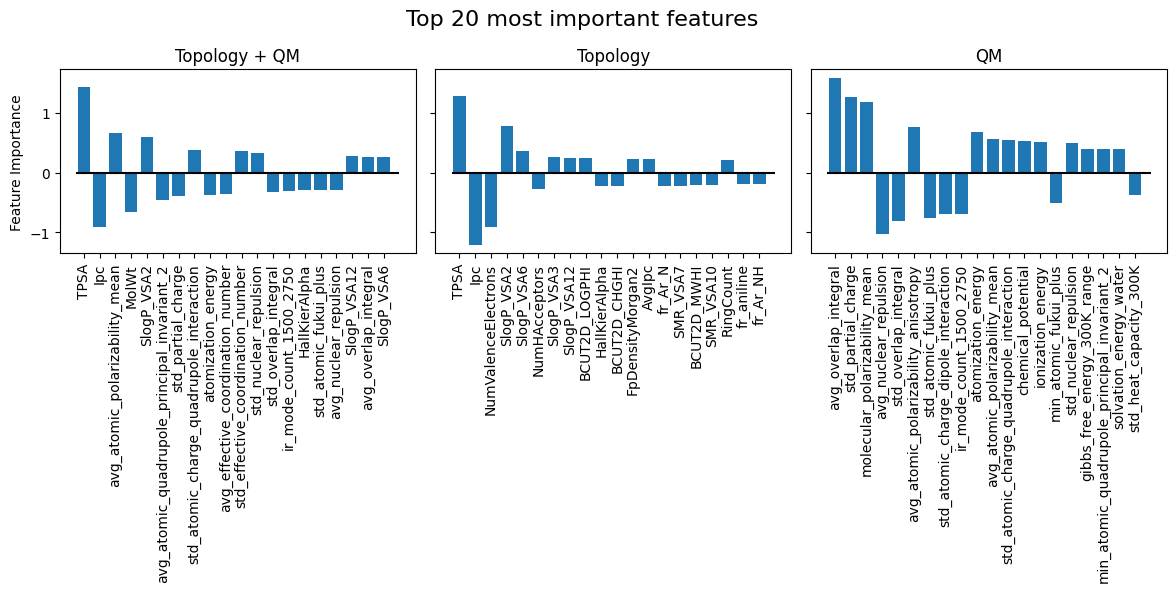

In [59]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

ax1.bar(keys_combo, values_combo)
ax2.bar(keys_topo, values_topo)
ax3.bar(keys_qm, values_qm)

ax1.hlines(0, -0.5, 20, "black")
ax2.hlines(0, -0.5, 20, "black")
ax3.hlines(0, -0.5, 20, "black")

ax1.tick_params(axis='x', rotation=90)
ax2.tick_params(axis='x', rotation=90)
ax3.tick_params(axis='x', rotation=90)

ax1.set_title("Topology + QM")
ax2.set_title("Topology")
ax3.set_title("QM")

ax1.set_ylabel("Feature Importance")

plt.suptitle("Top 20 most important features", fontsize=16)
plt.tight_layout()
plt.show()

So, after removing the topological features from the QFP feature set, it seems like a lot of QM features have gained more importance for the Topology + QM feature set

In [76]:
topo_r2s = scores_topo_pure["test_r2"]
combo_r2s = scores_combo_pure["test_r2"]

comparator = StatisticalComparison(combo_r2s, topo_r2s)
ttest_result =  comparator.nadeau_bengio_corrected_t_test(n_train, n_test)
wilcoxon_result = comparator.wilcoxon_fold_differences()

print("Topo mean r2:", np.abs(topo_r2s).mean())
print("Combined mean r2:", np.abs(combo_r2s).mean())
print("Mean improvement:", ttest_result["mean_diff"])
print(f"T-test p-value: {ttest_result["p_value"]} ->{' not' if ttest_result["p_value"] > 0.05 else ''} statistically significant")
print(f"Wilcoxon p-value: {wilcoxon_result['p_value_w']} ->{' not' if wilcoxon_result['p_value_w'] > 0.05 else ''} statistically significant")

Topo mean r2: 0.8161804537353434
Combined mean r2: 0.8237597096941254
Mean improvement: 0.007579255958781786
T-test p-value: 0.14277125547411096 -> not statistically significant
Wilcoxon p-value: 5.3882598876953125e-05 -> statistically significant


In [98]:
from collections import Counter

all_params = [estimator.best_params_ for estimator in scores_combo_pure["estimator"]]

count = Counter(tuple(p.items()) for p in all_params)
most_common = count.most_common(1)
best_params = dict(most_common[0][0])
best_params

{'predict__alpha': 0.01, 'predict__epsilon': 2.0}